# BPMN Process Map — Helpdesk

Alternative to the DFG-based process performance map (notebook 02).
Uses pm4py's Petri net miners (Inductive, Alpha, or Alpha+) and converts the result to a **BPMN diagram** for cleaner visualization to discover a Petri net from the same event log
that the process performance map uses (i.e. all complete cases from the test set).

The Alpha Miner produces a structured workflow net rather than a directly-follows
graph: it discovers explicit places, transitions, and concurrency relationships.

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

import torch
import pandas as pd
from pm4py.objects.log.obj import EventLog, Trace, Event
import pm4py
from pm4py.visualization.petri_net import visualizer as pn_visualizer

from src.interpretability.config.helpdesk_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation

In [2]:
# === TEST MODE CONFIGURATION ===
TEST_MODE = True
CONFIG.use_improved = False  # set True for the improved variant
MAX_CASES = 1000

# Miner choice: 'inductive', 'alpha', or 'alpha_plus'
MINER = 'inductive'

print(f'Dataset: {CONFIG.dataset_name}, test mode: {TEST_MODE} (max {MAX_CASES} cases)')
print(f'Miner: {MINER}')

Dataset: Helpdesk, test mode: True (max 1000 cases)
Miner: inductive


In [3]:
# Load model + data + Evaluation helper (same as notebook 02)
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model, dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat, all_num=CONFIG.all_num,
)

print(f'Available complete cases: {len(eval_helper.cases)}')

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

Available complete cases: 916


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

## Build pm4py event log

Same construction as `ProcessPerformanceMap.build_event_log()`: every complete
case is included, padding tokens are skipped, activities are decoded to names.

In [4]:
# Build activity index → name mapping
concept_id = eval_helper.concept_name_id
activity_labels = eval_helper.inverted_suffix_categories[concept_id]
eos_idx = next((i for i, n in activity_labels.items() if n == 'EOS'), None)

case_items = list(eval_helper.cases.items())
if TEST_MODE:
    case_items = case_items[:MAX_CASES]

log = EventLog()
for case_name, case_data in case_items:
    cat_tensors = case_data[0]
    activity_tensor = cat_tensors[concept_id]
    if activity_tensor.dim() > 1:
        activity_tensor = activity_tensor.squeeze(0)

    trace = Trace()
    trace.attributes['concept:name'] = str(case_name)

    for i, act_idx in enumerate(activity_tensor.tolist()):
        if act_idx == 0 or act_idx == eos_idx:
            continue
        name = activity_labels.get(act_idx, str(act_idx))
        event = Event()
        event['concept:name'] = name
        event['time:timestamp'] = pd.Timestamp('2020-01-01') + pd.Timedelta(hours=i)
        trace.append(event)

    if len(trace) > 0:
        log.append(trace)

n_events = sum(len(t) for t in log)
print(f'Event log: {len(log)} traces, {n_events} events')

Event log: 916 traces, 4245 events


## Collect model predictions for coloring

In [5]:
# Collect predictions via ProcessPerformanceMap (same coloring as notebook 02)
from src.interpretability.visualization.process_performance_map import ProcessPerformanceMap

ppm = ProcessPerformanceMap(
    model=model, test_dataset=test_dataset, eval_helper=eval_helper,
    activity_key=CONFIG.concept_name,
)
case_names = [c[0] for c in case_items] if TEST_MODE else None
ppm.collect_predictions(show_progress=True, case_names=case_names)
print(f'Collected predictions for {len(ppm.predictions)} prefixes')

Collected 3329 predictions
Found 40 unique transitions
Collected predictions for 3329 prefixes


## Mine Petri net and convert to BPMN

In [6]:
# Mine a Petri net first, then convert to BPMN.
# pm4py only exposes BPMN discovery via the Inductive Miner directly,
# but Petri nets from any miner can be converted to BPMN.
if MINER == 'inductive':
    net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(log)
elif MINER == 'alpha':
    net, initial_marking, final_marking = pm4py.discover_petri_net_alpha(log)
elif MINER == 'alpha_plus':
    net, initial_marking, final_marking = pm4py.discover_petri_net_alpha_plus(log)
else:
    raise ValueError(f"Unknown MINER {MINER!r}; expected 'inductive', 'alpha', or 'alpha_plus'")

bpmn = pm4py.convert_to_bpmn(net, initial_marking, final_marking)

n_tasks = sum(1 for n in bpmn.get_nodes() if hasattr(n, 'get_name') and n.__class__.__name__ == 'Task')
n_gateways = sum(1 for n in bpmn.get_nodes() if 'Gateway' in n.__class__.__name__)
n_events = sum(1 for n in bpmn.get_nodes() if 'Event' in n.__class__.__name__)
n_flows = len(bpmn.get_flows())
print(f'Mined with {MINER} → BPMN')
print(f'  Tasks: {n_tasks}, Gateways: {n_gateways}, Events: {n_events}, Flows: {n_flows}')

Mined with inductive → BPMN
  Tasks: 13, Gateways: 44, Events: 2, Flows: 84


## Visualize BPMN with PPM coloring

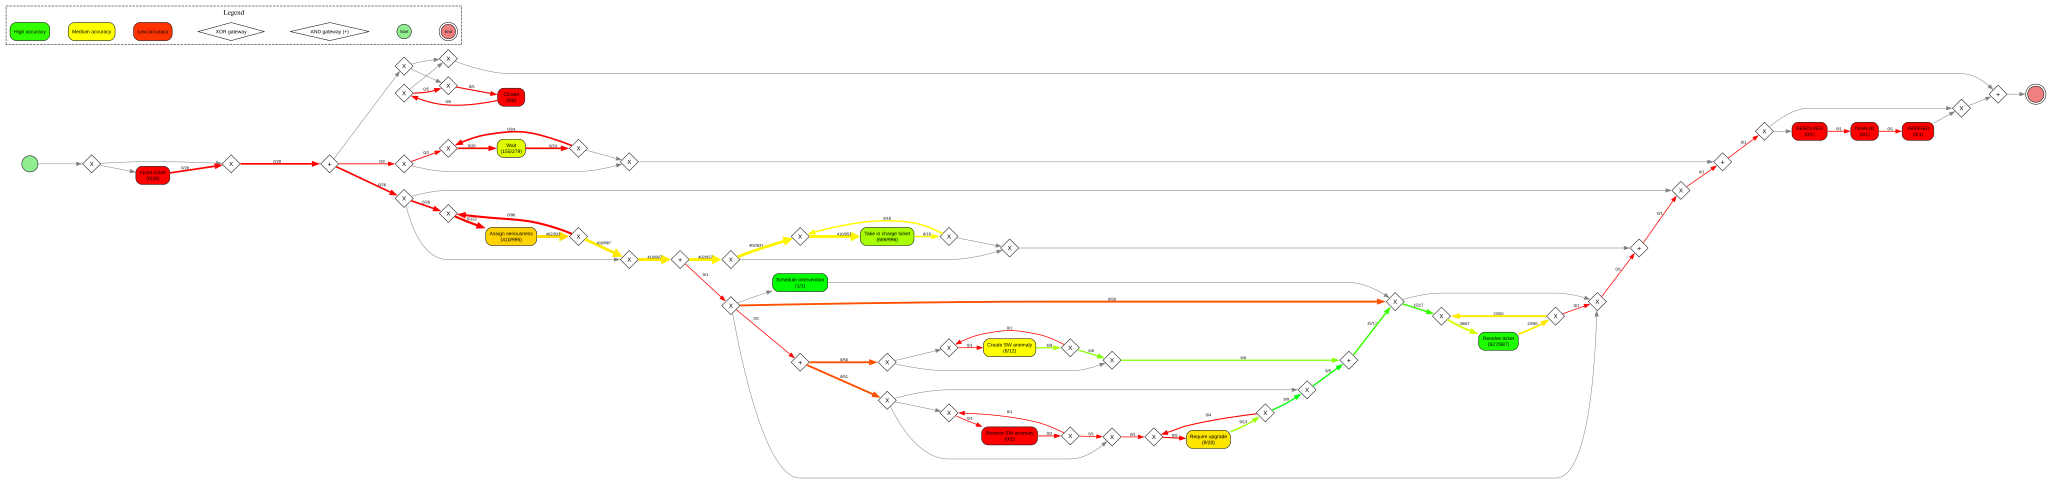

In [7]:
import graphviz
import numpy as np
from pm4py.objects.bpmn.obj import BPMN

# --- Translate activity names → PPM index-string keys ---
concept_id = eval_helper.concept_name_id
idx_to_label = eval_helper.inverted_suffix_categories[concept_id]
name_to_key = {label: str(idx) for idx, label in idx_to_label.items()}

def to_key(name):
    return name_to_key.get(name, name)

# --- Per-activity accuracy (for task fill colors) ---
act_perf = {}
for (src, tgt), perf in ppm.transition_performance.items():
    if src not in act_perf:
        act_perf[src] = [0, 0]
    act_perf[src][0] += perf.correct_count
    act_perf[src][1] += perf.total_count

# --- Per-(A,B) accuracy for arc colors ---
pair_perf = {(s, t): (p.correct_count, p.total_count)
             for (s, t), p in ppm.transition_performance.items()}

def acc_color(acc):
    if acc < 0.5:
        r, g, b = 255, int(255 * acc * 2), 0
    else:
        r, g, b = int(255 * (1 - (acc - 0.5) * 2)), 255, 0
    return f'#{r:02x}{g:02x}{b:02x}'

# --- Helpers to walk through gateways and find adjacent tasks ---
def downstream_tasks(node, visited=None, depth=0):
    """Find task nodes reachable from this node, walking through gateways."""
    if visited is None:
        visited = set()
    if id(node) in visited or depth > 5:
        return set()
    visited.add(id(node))
    if isinstance(node, BPMN.Task):
        return {node.get_name()}
    result = set()
    for flow in bpmn.get_flows():
        if flow.get_source() is node:
            result |= downstream_tasks(flow.get_target(), visited, depth + 1)
    return result

def upstream_tasks(node, visited=None, depth=0):
    if visited is None:
        visited = set()
    if id(node) in visited or depth > 5:
        return set()
    visited.add(id(node))
    if isinstance(node, BPMN.Task):
        return {node.get_name()}
    result = set()
    for flow in bpmn.get_flows():
        if flow.get_target() is node:
            result |= upstream_tasks(flow.get_source(), visited, depth + 1)
    return result

def flow_accuracy(flow):
    src = flow.get_source()
    tgt = flow.get_target()
    src_tasks = {src.get_name()} if isinstance(src, BPMN.Task) else upstream_tasks(src)
    tgt_tasks = {tgt.get_name()} if isinstance(tgt, BPMN.Task) else downstream_tasks(tgt)
    correct = total = 0
    for A in src_tasks:
        for B in tgt_tasks:
            c, t = pair_perf.get((to_key(A), to_key(B)), (0, 0))
            correct += c
            total += t
    return (correct, total) if total > 0 else None

# --- Build the graphviz Digraph ---
dot = graphviz.Digraph('BPMN', graph_attr={'rankdir': 'LR', 'bgcolor': 'white'})
dot.attr('node', fontname='Arial')
dot.attr('edge', fontname='Arial')

# Nodes
for node in bpmn.get_nodes():
    nid = str(id(node))
    cls = node.__class__.__name__
    if isinstance(node, BPMN.Task):
        name = node.get_name()
        correct, total = act_perf.get(to_key(name), (0, 0))
        if total > 0:
            acc = correct / total
            fill = acc_color(acc)
            label = f'{name}\\n({correct}/{total})'
        else:
            fill = 'white'
            label = name
        dot.node(nid, label=label, shape='box', style='rounded,filled',
                 fillcolor=fill, fontsize='10')
    elif 'StartEvent' in cls:
        dot.node(nid, label='', shape='circle', style='filled',
                 fillcolor='lightgreen', width='0.45', fixedsize='true')
    elif 'EndEvent' in cls:
        dot.node(nid, label='', shape='doublecircle', style='filled',
                 fillcolor='lightcoral', width='0.45', fixedsize='true')
    elif 'ExclusiveGateway' in cls:
        dot.node(nid, label='X', shape='diamond', style='filled',
                 fillcolor='white', width='0.5', height='0.5', fixedsize='true', fontsize='12')
    elif 'ParallelGateway' in cls:
        dot.node(nid, label='+', shape='diamond', style='filled',
                 fillcolor='white', width='0.5', height='0.5', fixedsize='true', fontsize='14')
    elif 'Gateway' in cls:
        dot.node(nid, label='?', shape='diamond', style='filled',
                 fillcolor='white', width='0.5', height='0.5', fixedsize='true', fontsize='12')
    else:
        dot.node(nid, label=cls, shape='ellipse')

# Flows
for flow in bpmn.get_flows():
    src_id = str(id(flow.get_source()))
    tgt_id = str(id(flow.get_target()))
    stats = flow_accuracy(flow)
    if stats is not None:
        correct, total = stats
        acc = correct / total
        color = acc_color(acc)
        penwidth = str(1 + np.log1p(total) * 0.7)
        label = f'{correct}/{total}'
        dot.edge(src_id, tgt_id, color=color, penwidth=penwidth,
                 label=label, fontsize='8')
    else:
        dot.edge(src_id, tgt_id, color='gray50', penwidth='1')

# Legend
with dot.subgraph(name='cluster_legend') as legend:
    legend.attr(label='Legend', style='dashed')
    legend.node('high_acc', 'High accuracy', shape='box', style='rounded,filled',
                fillcolor=acc_color(0.9), fontsize='10')
    legend.node('mid_acc', 'Medium accuracy', shape='box', style='rounded,filled',
                fillcolor=acc_color(0.5), fontsize='10')
    legend.node('low_acc', 'Low accuracy', shape='box', style='rounded,filled',
                fillcolor=acc_color(0.1), fontsize='10')
    legend.node('xor_legend', 'XOR gateway', shape='diamond', style='filled',
                fillcolor='white', fontsize='10')
    legend.node('and_legend', 'AND gateway (+)', shape='diamond', style='filled',
                fillcolor='white', fontsize='10')
    legend.node('start_legend', 'Start', shape='circle', style='filled',
                fillcolor='lightgreen', width='0.4', fixedsize='true', fontsize='8')
    legend.node('end_legend', 'End', shape='doublecircle', style='filled',
                fillcolor='lightcoral', width='0.4', fixedsize='true', fontsize='8')
    legend.edge('high_acc', 'mid_acc', style='invis')
    legend.edge('mid_acc', 'low_acc', style='invis')
    legend.edge('low_acc', 'xor_legend', style='invis')
    legend.edge('xor_legend', 'and_legend', style='invis')
    legend.edge('and_legend', 'start_legend', style='invis')
    legend.edge('start_legend', 'end_legend', style='invis')

dot

## Comparison with the DFG-based map

Unlike the DFG (notebook 02), the Alpha-mined Petri net:
- Uses **places** to make causal/parallel/choice relationships explicit
- Has a clear initial and final marking (start/end)
- Cannot represent loops well — Alpha Miner has known limitations with short loops,
  invisible/duplicate tasks, and noise

For Helpdesk specifically, expect a complex net since the log contains many activities
with optional behavior. If the net looks too permissive due to noise, switch to the Inductive Miner Infrequent variant (`pm4py.discover_petri_net_inductive(log, noise_threshold=0.2)`) with a noise threshold.